###Factor Analysis Practice from Data Camp

In [2]:
!pip install factor_analyzer
import pandas as pd
from sklearn.datasets import load_iris
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42564 sha256=36b82837b01ba02b8687d3a9ef831e020e7cdbc22a53dd7f20ca133039b350f5
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer


In [4]:
# Load Data
df = pd.read_csv("bfi.csv")

In [5]:
# Preprocess Data
df.columns

Index(['rownames', 'A1', 'A2', 'A3', 'A4', 'A5', 'C1', 'C2', 'C3', 'C4', 'C5',
       'E1', 'E2', 'E3', 'E4', 'E5', 'N1', 'N2', 'N3', 'N4', 'N5', 'O1', 'O2',
       'O3', 'O4', 'O5', 'gender', 'education', 'age'],
      dtype='object')

In [7]:
# Drop Unnecessary Columns
df.drop(['gender' ,'education', 'age'], axis = 1, inplace = True)

In [8]:
df.dropna(inplace = True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2436 entries, 0 to 2799
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  2436 non-null   int64  
 1   A1        2436 non-null   float64
 2   A2        2436 non-null   float64
 3   A3        2436 non-null   float64
 4   A4        2436 non-null   float64
 5   A5        2436 non-null   float64
 6   C1        2436 non-null   float64
 7   C2        2436 non-null   float64
 8   C3        2436 non-null   float64
 9   C4        2436 non-null   float64
 10  C5        2436 non-null   float64
 11  E1        2436 non-null   float64
 12  E2        2436 non-null   float64
 13  E3        2436 non-null   float64
 14  E4        2436 non-null   float64
 15  E5        2436 non-null   float64
 16  N1        2436 non-null   float64
 17  N2        2436 non-null   float64
 18  N3        2436 non-null   float64
 19  N4        2436 non-null   float64
 20  N5        2436 non-null   float64
 

In [10]:
df.head()

,rownames,A1,A2,A3,A4,A5,C1,C2,C3,C4,...,N1,N2,N3,N4,N5,O1,O2,O3,O4,O5
0,61617,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,...,3.0,4.0,2.0,2.0,3.0,3.0,6,3.0,4.0,3.0
1,61618,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,...,3.0,3.0,3.0,5.0,5.0,4.0,2,4.0,3.0,3.0
2,61620,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,...,4.0,5.0,4.0,2.0,3.0,4.0,2,5.0,5.0,2.0
3,61621,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,...,2.0,5.0,2.0,4.0,1.0,3.0,3,4.0,3.0,5.0
4,61622,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,...,2.0,3.0,4.0,4.0,3.0,3.0,3,4.0,3.0,3.0


In [11]:
# Barlett's Test of Sphericity
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value=calculate_bartlett_sphericity(df)
chi_square_value, p_value

(18184.30630782077, 0.0)

In [12]:
# KMO Test
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model=calculate_kmo(df)

In [13]:
kmo_model

0.8483267027192372

In [14]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation=None)
fa.fit(df)

FactorAnalyzer(rotation=None, rotation_kwargs={})

In [17]:
# Choosing the Number of Factors
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=25, rotation=None)
fa.fit(df)
# Check Eigenvalues
ev, v = fa.get_eigenvalues()
ev

array([5.13457985, 2.75337527, 2.14814212, 1.85250623, 1.54846254,
       1.11066151, 0.98067695, 0.82430872, 0.79516217, 0.71828982,
       0.68602566, 0.67614851, 0.65177562, 0.62297416, 0.59623084,
       0.56244599, 0.54329886, 0.51434031, 0.49437154, 0.48263949,
       0.44865495, 0.42280589, 0.40028481, 0.38773757, 0.38183723,
       0.2622634 ])

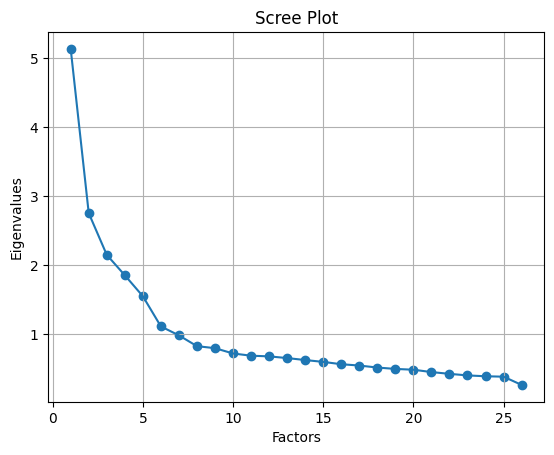

In [18]:
# Create scree plot using matplotlib
plt.scatter(range(1, df.shape[1]+1),ev)
plt.plot(range(1,df.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel("Factors")
plt.ylabel('Eigenvalues')
plt.grid()
plt.show()

In [22]:
# Perform Factor Analysis
fa = FactorAnalyzer(n_factors = 6, rotation="varimax")
fa.fit(df)

FactorAnalyzer(n_factors=6, rotation='varimax', rotation_kwargs={})

In [27]:
loadings = fa.loadings_
print(loadings)

[[-0.02290301 -0.03247244  0.03316871 -0.03809335  0.00379506  0.10374846]
 [ 0.09939617  0.06047378  0.02669442 -0.53078469 -0.12030937  0.16363838]
 [ 0.03176731  0.259875    0.1402256   0.64656947  0.05577021 -0.09704963]
 [-0.00525556  0.40884857  0.10953353  0.58700379  0.01618433  0.03914857]
 [-0.07926603  0.25534237  0.22930808  0.39176033 -0.13629257  0.03340065]
 [-0.14364476  0.4910488   0.0856494   0.45108988  0.00911122  0.10588827]
 [ 0.00562295  0.12364715  0.54015018  0.00422137  0.18345833  0.13879815]
 [ 0.08435816  0.10650466  0.65249593  0.05653766  0.0792028   0.20858043]
 [-0.03394649  0.0497959   0.54587749  0.10028627 -0.0123717   0.05447959]
 [ 0.23161662  0.0089893  -0.67278539 -0.08998026 -0.15345088  0.22697701]
 [ 0.29340234 -0.1436436  -0.55970426 -0.04706994  0.0256143   0.09577898]
 [ 0.05310218 -0.52147723  0.02649196 -0.09054497 -0.05928098  0.33201867]
 [ 0.2631889  -0.62292324 -0.11075758 -0.07455019 -0.03044005  0.29120362]
 [ 0.00119     0.63056485

In [29]:
# Perform Factor Analysis on the Top 5 Factors
fa = FactorAnalyzer(n_factors = 5, rotation="varimax")
fa.fit(df)
fa.loadings_

array([[-0.01924556, -0.06170286,  0.03486479, -0.01867751,  0.0143449 ],
       [ 0.1064546 ,  0.0307053 ,  0.02756749, -0.42961248, -0.07413314],
       [ 0.02869339,  0.22712712,  0.14115892,  0.62180104,  0.0641174 ],
       [ 0.0053354 ,  0.32992706,  0.11592822,  0.64285597,  0.06164725],
       [-0.06944324,  0.2092169 ,  0.23541803,  0.43124101, -0.10864741],
       [-0.12900241,  0.39769   ,  0.09790092,  0.52815947,  0.0753634 ],
       [ 0.00954751,  0.04829695,  0.54827569,  0.04119434,  0.21216878],
       [ 0.08997526,  0.01445863,  0.65030388,  0.10569283,  0.11658219],
       [-0.03024319,  0.01082522,  0.55578126,  0.11416497, -0.00481157],
       [ 0.24079401, -0.03932582, -0.63357583, -0.04146169, -0.1096952 ],
       [ 0.29433007, -0.15417946, -0.56699105, -0.04785845,  0.03126425],
       [ 0.05706633, -0.57646013,  0.01718243, -0.08965972, -0.07321838],
       [ 0.2616608 , -0.67156053, -0.12149036, -0.09678776, -0.05968008],
       [ 0.01241719,  0.53305616,  0.0

In [30]:
# Get the variance of each factor
fa.get_factor_variance()

(array([2.73610909, 2.42804922, 2.08250384, 1.80050522, 1.54950195]),
 array([0.10523496, 0.09338651, 0.0800963 , 0.0692502 , 0.05959623]),
 array([0.10523496, 0.19862147, 0.27871777, 0.34796798, 0.4075642 ]))

##### Total 41% cumulative variance explained by the 5 factors